# 89 — STRAT-005 Timing Refinement

**Hypothesis**: Daily signals decide *when* to buy; sub-daily data picks the *best intraday entry price*.

Notebook 88 found daily resolution dominates (+1,664%, Sharpe 1.30) but sub-daily detects dips 12-48 hours earlier.
This notebook tests whether using h4/hourly data to optimize the entry price within a daily entry window improves performance.

## Timing Methods Tested
| # | Method | Logic |
|---|--------|-------|
| 1 | **Daily baseline** | Enter at daily close when signal fires (control) |
| 2 | **H4 first signal** | Enter at first h4 bar where 4/5 conditions met |
| 3 | **H4 lowest price** | Enter at lowest h4 price within the entry window |
| 4 | **H4 best SOPR** | Enter at h4 bar with lowest STH-SOPR (deepest capitulation) |
| 5 | **Hourly first signal** | Enter at first hourly bar where 4/5 conditions met |

**Exit**: Identical for all methods — daily MVRV>2 AND Price<50-day MA.

In [1]:
import pandas as pd
import numpy as np
import vectorbt as vbt
from pathlib import Path
from datetime import datetime, timedelta
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('.').resolve().parent
BL_DIR = PROJECT_ROOT / 'data' / 'bl'
GN_HOURLY = PROJECT_ROOT / 'data' / 'glassnode' / 'hourly'

BACKTEST_START = '2020-02-02'
ENTRY_WINDOW_DAYS = 1  # ±1 day search window around daily entry

print(f'Project root: {PROJECT_ROOT}')
print(f'Backtest start: {BACKTEST_START}')
print(f'Entry window: ±{ENTRY_WINDOW_DAYS} day around daily signal')

Project root: /Users/fester/Documents/bitcoin-lab-btc-data-pipeline
Backtest start: 2020-02-02
Entry window: ±1 day around daily signal


## 1. Setup & Data Loading

In [2]:
def load_parquet(path: Path) -> pd.Series:
    """Load a parquet file and return a time-indexed Series."""
    if not path.exists():
        print(f'WARNING: {path} not found')
        return pd.Series(dtype=float)
    df = pd.read_parquet(path)
    time_col = next((c for c in ['time', 'date', 'timestamp'] if c in df.columns), None)
    if time_col is None and isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        time_col = df.columns[0]
    val_col = 'value' if 'value' in df.columns else next((c for c in df.columns if c not in ['time', 'date', 'timestamp']), None)
    s = df.set_index(time_col)[val_col].sort_index()
    s.index = pd.to_datetime(s.index)
    if s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s.astype(float)


def load_resolution_data(res_dir: Path) -> dict:
    """Load all STRAT-005 metrics for a given resolution."""
    data = {}
    for metric in ['price', 'mvrv', 'mvrv_sth', 'sopr_sth', 'realized_profit', 'realized_loss']:
        data[metric] = load_parquet(res_dir / f'{metric}.parquet')
    return data


# Load Glassnode hourly derivatives
funding_hourly = load_parquet(GN_HOURLY / 'funding_rate.parquet')
liq_long_hourly = load_parquet(GN_HOURLY / 'liquidations_long.parquet')
liq_short_hourly = load_parquet(GN_HOURLY / 'liquidations_short.parquet')

print(f'Funding (hourly):  {funding_hourly.index.min()} → {funding_hourly.index.max()} ({len(funding_hourly)} rows)')
print(f'Liq long (hourly): {liq_long_hourly.index.min()} → {liq_long_hourly.index.max()} ({len(liq_long_hourly)} rows)')
print(f'Liq short (hourly):{liq_short_hourly.index.min()} → {liq_short_hourly.index.max()} ({len(liq_short_hourly)} rows)')

# Load all 3 resolutions
data_daily = load_resolution_data(BL_DIR / 'daily')
data_h4 = load_resolution_data(BL_DIR / 'h4')
data_hourly = load_resolution_data(BL_DIR / 'hourly')

for name, d in [('daily', data_daily), ('h4', data_h4), ('hourly', data_hourly)]:
    p = d['price']
    print(f'{name:8s}: {len(p):>7,} rows  |  {p.index.min().date()} → {p.index.max()}  |  last: ${p.iloc[-1]:,.0f}')

Funding (hourly):  2020-02-02 00:00:00 → 2026-01-30 12:00:00 (52549 rows)
Liq long (hourly): 2019-03-30 00:00:00 → 2026-01-30 11:00:00 (59964 rows)
Liq short (hourly):2019-03-30 00:00:00 → 2026-01-30 11:00:00 (59964 rows)


daily   :   4,047 rows  |  2015-01-01 → 2026-01-29 00:00:00  |  last: $87,002
h4      :  24,285 rows  |  2015-01-01 → 2026-01-30 08:00:00  |  last: $82,559
hourly  :  96,901 rows  |  2015-01-01 → 2026-01-30 11:00:00  |  last: $82,696


## 2. Identify Daily Entry Windows

Run daily BTD signal generation (4/5 conditions) and extract contiguous entry episodes.

In [3]:
def generate_daily_signals(data: dict, funding: pd.Series, liq_long: pd.Series, liq_short: pd.Series) -> pd.DataFrame:
    """Generate STRAT-005 entry/exit signals on daily resolution."""
    price = data['price']
    idx = price.index
    
    df = pd.DataFrame(index=idx)
    df['price'] = price
    df['mvrv'] = data['mvrv'].reindex(idx, method='ffill')
    df['mvrv_sth'] = data['mvrv_sth'].reindex(idx, method='ffill')
    df['sopr_sth'] = data['sopr_sth'].reindex(idx, method='ffill')
    df['realized_profit'] = data['realized_profit'].reindex(idx, method='ffill')
    df['realized_loss'] = data['realized_loss'].reindex(idx, method='ffill')
    
    # Forward-fill hourly derivatives to daily
    df['funding'] = funding.reindex(idx, method='ffill')
    df['liq_long'] = liq_long.reindex(idx, method='ffill')
    df['liq_short'] = liq_short.reindex(idx, method='ffill')
    
    df['rpl_ratio'] = df['realized_profit'] / df['realized_loss'].replace(0, np.nan)
    
    # Entry conditions
    df['cond_sth_mvrv'] = df['mvrv_sth'] < 1.0
    df['cond_sth_sopr'] = df['sopr_sth'] < 1.0
    df['cond_rpl'] = df['rpl_ratio'] < 1.0
    df['cond_funding'] = df['funding'] <= 0.0
    df['cond_liq'] = df['liq_long'] > df['liq_short']
    
    df['btd_count'] = (
        df['cond_sth_mvrv'].astype(int) +
        df['cond_sth_sopr'].astype(int) +
        df['cond_rpl'].astype(int) +
        df['cond_funding'].astype(int) +
        df['cond_liq'].astype(int)
    )
    df['entry_signal'] = df['btd_count'] >= 4
    
    # Exit: MVRV > 2.0 AND Price < 50-day MA
    df['price_ma50'] = df['price'].rolling(50, min_periods=50).mean()
    df['exit_signal'] = (df['mvrv'] > 2.0) & (df['price'] < df['price_ma50'])
    
    return df.loc[BACKTEST_START:]


daily_df = generate_daily_signals(data_daily, funding_hourly, liq_long_hourly, liq_short_hourly)
print(f'Daily bars: {len(daily_df)}')
print(f'Entry bars: {daily_df["entry_signal"].sum()}')
print(f'Exit bars:  {daily_df["exit_signal"].sum()}')

Daily bars: 2189
Entry bars: 397
Exit bars:  196


In [4]:
def extract_entry_episodes(daily_df: pd.DataFrame) -> pd.DataFrame:
    """Extract contiguous blocks of entry=True bars as episodes.
    
    Returns DataFrame with columns: episode_id, start_date, end_date, daily_entry_price, n_days
    Each episode represents a contiguous block of daily entry signals.
    We enter on the FIRST day of each episode (as VectorBT would).
    """
    entry = daily_df['entry_signal'].copy()
    # Find episode starts: entry=True preceded by False (or first bar)
    starts = entry & ~entry.shift(1, fill_value=False)
    # Find episode ends: entry=True followed by False (or last bar)
    ends = entry & ~entry.shift(-1, fill_value=False)
    
    start_dates = starts[starts].index
    end_dates = ends[ends].index
    
    # Match starts and ends
    episodes = []
    for i, sd in enumerate(start_dates):
        # Find the corresponding end date (first end_date >= start_date)
        ed = end_dates[end_dates >= sd][0] if len(end_dates[end_dates >= sd]) > 0 else sd
        n_days = (ed - sd).days + 1
        daily_price = daily_df.loc[sd, 'price']
        episodes.append({
            'episode_id': i + 1,
            'start_date': sd,
            'end_date': ed,
            'daily_entry_price': daily_price,
            'n_days': n_days,
        })
    
    return pd.DataFrame(episodes)


episodes = extract_entry_episodes(daily_df)
print(f'Found {len(episodes)} entry episodes\n')
print(episodes.to_string(index=False, float_format='${:,.0f}'.format))

Found 180 entry episodes

 episode_id start_date   end_date  daily_entry_price  n_days
          1 2020-02-26 2020-02-26             $9,002       1
          2 2020-03-08 2020-03-08             $8,586       1
          3 2020-03-10 2020-03-18             $7,951       9
          4 2020-03-20 2020-03-21             $6,429       2
          5 2020-03-23 2020-03-23             $6,181       1
          6 2020-03-25 2020-03-25             $6,678       1
          7 2020-03-27 2020-04-01             $6,666       6
          8 2020-04-04 2020-04-04             $6,788       1
          9 2020-04-10 2020-04-16             $6,965       7
         10 2020-04-20 2020-04-21             $7,036       2
         11 2020-05-26 2020-05-26             $8,857       1
         12 2020-09-06 2020-09-06            $10,223       1
         13 2020-09-23 2020-09-23            $10,410       1
         14 2021-05-16 2021-05-17            $47,653       2
         15 2021-05-19 2021-05-23            $38,785       

## 3. Define Intraday Timing Methods

For each daily entry episode, search within a ±1 day window for optimal sub-daily entry.

In [5]:
def build_subdaily_signals(data: dict, funding: pd.Series, liq_long: pd.Series, 
                           liq_short: pd.Series, freq: str) -> pd.DataFrame:
    """Build sub-daily signal DataFrame with all conditions computed."""
    price = data['price']
    idx = price.index
    
    df = pd.DataFrame(index=idx)
    df['price'] = price
    df['mvrv_sth'] = data['mvrv_sth'].reindex(idx, method='ffill')
    df['sopr_sth'] = data['sopr_sth'].reindex(idx, method='ffill')
    df['realized_profit'] = data['realized_profit'].reindex(idx, method='ffill')
    df['realized_loss'] = data['realized_loss'].reindex(idx, method='ffill')
    
    # Forward-fill hourly derivatives
    df['funding'] = funding.reindex(idx, method='ffill')
    df['liq_long'] = liq_long.reindex(idx, method='ffill')
    df['liq_short'] = liq_short.reindex(idx, method='ffill')
    
    df['rpl_ratio'] = df['realized_profit'] / df['realized_loss'].replace(0, np.nan)
    
    # Entry conditions
    df['cond_sth_mvrv'] = df['mvrv_sth'] < 1.0
    df['cond_sth_sopr'] = df['sopr_sth'] < 1.0
    df['cond_rpl'] = df['rpl_ratio'] < 1.0
    df['cond_funding'] = df['funding'] <= 0.0
    df['cond_liq'] = df['liq_long'] > df['liq_short']
    
    df['btd_count'] = (
        df['cond_sth_mvrv'].astype(int) +
        df['cond_sth_sopr'].astype(int) +
        df['cond_rpl'].astype(int) +
        df['cond_funding'].astype(int) +
        df['cond_liq'].astype(int)
    )
    df['entry_signal'] = df['btd_count'] >= 4
    
    return df.loc[BACKTEST_START:]


# Build sub-daily signal DataFrames
h4_df = build_subdaily_signals(data_h4, funding_hourly, liq_long_hourly, liq_short_hourly, '4h')
hourly_df = build_subdaily_signals(data_hourly, funding_hourly, liq_long_hourly, liq_short_hourly, '1h')

print(f'H4 bars:     {len(h4_df):>7,}  |  entry bars: {h4_df["entry_signal"].sum()}')
print(f'Hourly bars: {len(hourly_df):>7,}  |  entry bars: {hourly_df["entry_signal"].sum()}')

H4 bars:      13,137  |  entry bars: 2183
Hourly bars:  52,391  |  entry bars: 8256


## 4. Implement Timing Methods

For each daily entry episode, find the optimal entry point using each timing method.

In [6]:
def find_timing_entries(episodes: pd.DataFrame, daily_df: pd.DataFrame,
                        h4_df: pd.DataFrame, hourly_df: pd.DataFrame,
                        window_days: int = 1) -> pd.DataFrame:
    """For each episode, find entry price/time using each timing method.
    
    Search window: from (episode_start - window_days) to (episode_start + window_days).
    
    Methods:
    1. Daily baseline: enter at daily close on start_date
    2. H4 first signal: first h4 bar with 4/5 conditions in window
    3. H4 lowest price: lowest h4 price in window
    4. H4 best SOPR: h4 bar with lowest STH-SOPR in window
    5. Hourly first signal: first hourly bar with 4/5 conditions in window
    """
    rows = []
    
    for _, ep in episodes.iterrows():
        ep_id = ep['episode_id']
        start = ep['start_date']
        
        # Define search window
        win_start = start - pd.Timedelta(days=window_days)
        win_end = start + pd.Timedelta(days=window_days + 1)  # +1 to include end of day
        
        # Method 1: Daily baseline
        rows.append({
            'episode_id': ep_id,
            'method': '1_daily_baseline',
            'entry_time': start,
            'entry_price': ep['daily_entry_price'],
        })
        
        # H4 data in window
        h4_win = h4_df.loc[win_start:win_end]
        
        # Method 2: H4 first signal
        h4_signals = h4_win[h4_win['entry_signal']]
        if len(h4_signals) > 0:
            first_h4 = h4_signals.iloc[0]
            rows.append({
                'episode_id': ep_id,
                'method': '2_h4_first_signal',
                'entry_time': h4_signals.index[0],
                'entry_price': first_h4['price'],
            })
        else:
            # Fallback to daily if no h4 signal in window
            rows.append({
                'episode_id': ep_id,
                'method': '2_h4_first_signal',
                'entry_time': start,
                'entry_price': ep['daily_entry_price'],
            })
        
        # Method 3: H4 lowest price in window
        if len(h4_win) > 0:
            min_idx = h4_win['price'].idxmin()
            rows.append({
                'episode_id': ep_id,
                'method': '3_h4_lowest_price',
                'entry_time': min_idx,
                'entry_price': h4_win.loc[min_idx, 'price'],
            })
        else:
            rows.append({
                'episode_id': ep_id,
                'method': '3_h4_lowest_price',
                'entry_time': start,
                'entry_price': ep['daily_entry_price'],
            })
        
        # Method 4: H4 best SOPR (lowest STH-SOPR = deepest capitulation)
        if len(h4_win) > 0 and h4_win['sopr_sth'].notna().any():
            min_sopr_idx = h4_win['sopr_sth'].idxmin()
            rows.append({
                'episode_id': ep_id,
                'method': '4_h4_best_sopr',
                'entry_time': min_sopr_idx,
                'entry_price': h4_win.loc[min_sopr_idx, 'price'],
            })
        else:
            rows.append({
                'episode_id': ep_id,
                'method': '4_h4_best_sopr',
                'entry_time': start,
                'entry_price': ep['daily_entry_price'],
            })
        
        # Hourly data in window
        hr_win = hourly_df.loc[win_start:win_end]
        
        # Method 5: Hourly first signal
        hr_signals = hr_win[hr_win['entry_signal']]
        if len(hr_signals) > 0:
            first_hr = hr_signals.iloc[0]
            rows.append({
                'episode_id': ep_id,
                'method': '5_hourly_first_signal',
                'entry_time': hr_signals.index[0],
                'entry_price': first_hr['price'],
            })
        else:
            rows.append({
                'episode_id': ep_id,
                'method': '5_hourly_first_signal',
                'entry_time': start,
                'entry_price': ep['daily_entry_price'],
            })
    
    return pd.DataFrame(rows)


timing = find_timing_entries(episodes, daily_df, h4_df, hourly_df, window_days=ENTRY_WINDOW_DAYS)
print(f'Timing entries: {len(timing)} rows ({len(episodes)} episodes × 5 methods)')
print(f'\nMethods: {timing["method"].unique().tolist()}')

Timing entries: 900 rows (180 episodes × 5 methods)

Methods: ['1_daily_baseline', '2_h4_first_signal', '3_h4_lowest_price', '4_h4_best_sopr', '5_hourly_first_signal']


In [7]:
# Show the timing entries for each episode
pivot = timing.pivot(index='episode_id', columns='method', values='entry_price')
pivot.columns = [c.split('_', 1)[1] for c in pivot.columns]

# Add episode dates
pivot.insert(0, 'start_date', episodes.set_index('episode_id')['start_date'])

print('Entry prices by method and episode:')
print(pivot.to_string(float_format='${:,.0f}'.format))

Entry prices by method and episode:
           start_date  daily_baseline  h4_first_signal  h4_lowest_price  h4_best_sopr  hourly_first_signal
episode_id                                                                                                
1          2020-02-26          $9,002           $8,967           $8,720        $8,804               $8,743
2          2020-03-08          $8,586           $8,490           $7,792        $7,890               $8,603
3          2020-03-10          $7,951           $7,943           $7,664        $7,890               $7,885
4          2020-03-20          $6,429           $5,313           $5,313        $6,176               $5,373
5          2020-03-23          $6,181           $6,209           $5,868        $6,617               $6,316
6          2020-03-25          $6,678           $6,617           $6,556        $6,617               $6,572
7          2020-03-27          $6,666           $6,701           $6,174        $6,226               $6,708
8

## 5. Price Improvement Analysis

For each episode, how much better is the method's entry price vs daily baseline?

In [8]:
# Calculate price improvement vs daily baseline for each episode/method
baseline = timing[timing['method'] == '1_daily_baseline'].set_index('episode_id')['entry_price']

improvements = []
for _, row in timing.iterrows():
    ep_id = row['episode_id']
    daily_price = baseline.loc[ep_id]
    method_price = row['entry_price']
    # Positive = method got a better (lower) price
    improvement_pct = (daily_price - method_price) / daily_price * 100
    improvements.append({
        'episode_id': ep_id,
        'method': row['method'],
        'daily_price': daily_price,
        'method_price': method_price,
        'improvement_pct': improvement_pct,
    })

imp_df = pd.DataFrame(improvements)

# Summary stats per method
print('Price Improvement vs Daily Baseline (positive = better entry price):')
print('=' * 85)
print(f'{"Method":>25s}  |  {"Mean":>7s}  |  {"Median":>7s}  |  {"Std":>7s}  |  {"Min":>7s}  |  {"Max":>7s}  |  {"Better":>6s}')
print('-' * 85)

for method in timing['method'].unique():
    m = imp_df[imp_df['method'] == method]['improvement_pct']
    label = method.split('_', 1)[1]
    better = (m > 0).sum()
    total = len(m)
    print(f'{label:>25s}  |  {m.mean():>6.2f}%  |  {m.median():>6.2f}%  |  {m.std():>6.2f}%  |  {m.min():>6.2f}%  |  {m.max():>6.2f}%  |  {better}/{total}')

Price Improvement vs Daily Baseline (positive = better entry price):
                   Method  |     Mean  |   Median  |      Std  |      Min  |      Max  |  Better
-------------------------------------------------------------------------------------
           daily_baseline  |    0.00%  |    0.00%  |    0.00%  |    0.00%  |    0.00%  |  0/180
          h4_first_signal  |   -0.88%  |   -0.43%  |    3.41%  |  -15.31%  |   17.37%  |  65/180
          h4_lowest_price  |    2.98%  |    2.22%  |    2.55%  |    0.15%  |   17.37%  |  180/180
             h4_best_sopr  |    1.12%  |    0.71%  |    2.58%  |   -8.63%  |   10.80%  |  130/180
      hourly_first_signal  |   -1.15%  |   -0.74%  |    3.64%  |  -16.47%  |   16.43%  |  64/180


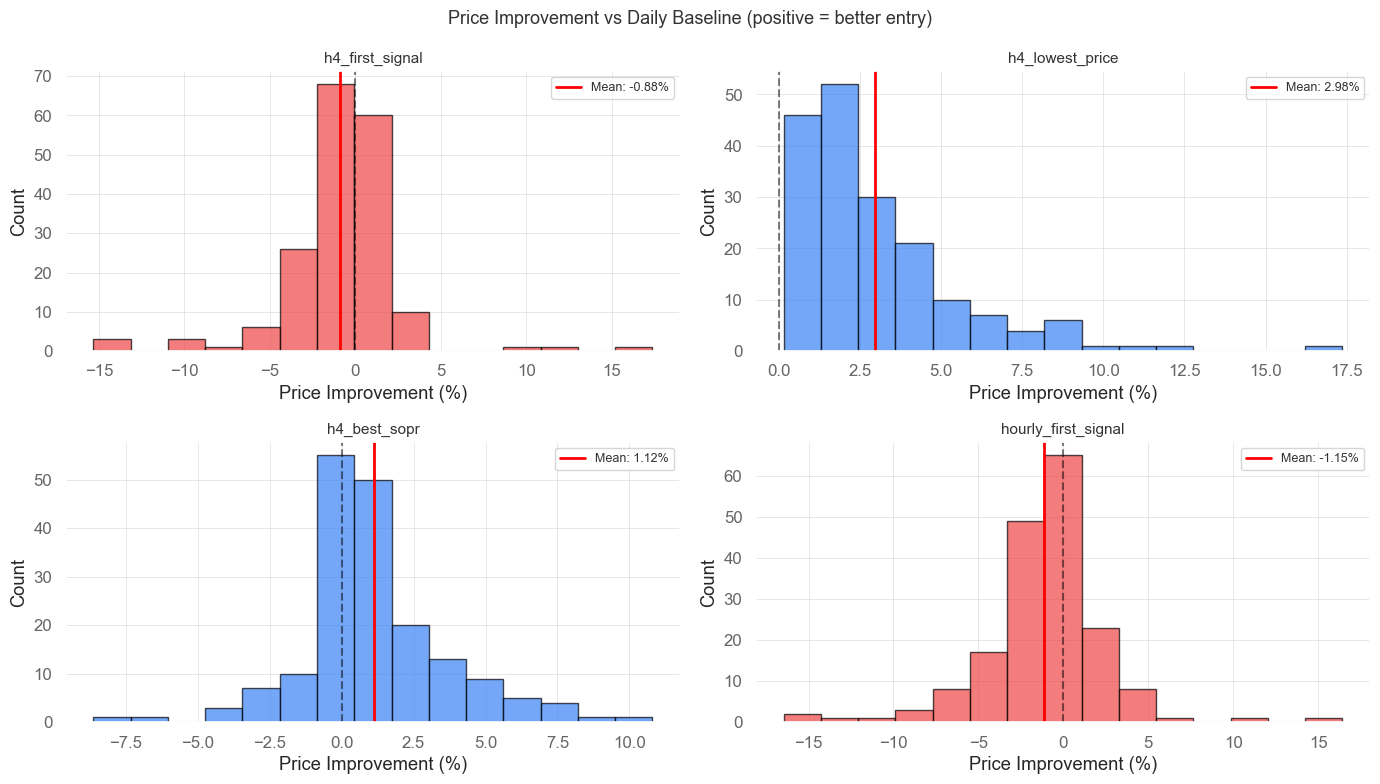

In [9]:
# Histogram of per-trade price improvement by method
methods_to_plot = [m for m in timing['method'].unique() if m != '1_daily_baseline']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, method in enumerate(methods_to_plot):
    ax = axes[i]
    m = imp_df[imp_df['method'] == method]['improvement_pct']
    label = method.split('_', 1)[1]
    
    ax.hist(m, bins=15, color='#3b82f6' if m.mean() > 0 else '#ef4444', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(m.mean(), color='red', linestyle='-', linewidth=2, label=f'Mean: {m.mean():.2f}%')
    ax.set_title(f'{label}', fontsize=11)
    ax.set_xlabel('Price Improvement (%)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig.suptitle('Price Improvement vs Daily Baseline (positive = better entry)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. VectorBT Backtests

Full backtest for each timing method. All methods use:
- **Same daily exit signal**: MVRV>2 AND Price<50-day MA
- **Same trade episodes**: Only the entry price differs
- **Daily frequency**: Trades held weeks/months, daily granularity sufficient

In [10]:
def run_method_backtest(daily_df: pd.DataFrame, episodes: pd.DataFrame,
                        timing: pd.DataFrame, method_name: str) -> dict:
    """Run VectorBT backtest for a specific timing method.
    
    Strategy: 
    - Enter on the first day of each episode at the method's entry price
    - Exit when daily exit_signal fires
    - Use adjusted close series that reflects the method's entry prices
    """
    method_entries = timing[timing['method'] == method_name].set_index('episode_id')
    
    # Build entry/exit boolean series on daily index
    price = daily_df['price'].copy()
    entries = pd.Series(False, index=price.index)
    exits = daily_df['exit_signal'].copy()
    
    # Mark entry on first day of each episode
    for _, ep in episodes.iterrows():
        sd = ep['start_date']
        if sd in entries.index:
            entries.loc[sd] = True
    
    # For methods with different entry prices, we adjust the close series
    # on entry days to reflect the method's actual entry price.
    # This way VectorBT computes returns from the actual entry price.
    adjusted_price = price.copy()
    for _, ep in episodes.iterrows():
        ep_id = ep['episode_id']
        sd = ep['start_date']
        if ep_id in method_entries.index and sd in adjusted_price.index:
            adjusted_price.loc[sd] = method_entries.loc[ep_id, 'entry_price']
    
    pf = vbt.Portfolio.from_signals(
        close=adjusted_price,
        entries=entries,
        exits=exits,
        fees=0.001,
        slippage=0.001,
        init_cash=10_000,
        freq='1D',
    )
    
    n_trades = pf.trades.count()
    return {
        'method': method_name,
        'portfolio': pf,
        'total_return': pf.total_return() * 100,
        'sharpe': pf.sharpe_ratio(),
        'max_dd': pf.max_drawdown() * 100,
        'n_trades': n_trades,
        'win_rate': pf.trades.win_rate() * 100 if n_trades > 0 else 0,
        'avg_trade': pf.trades.returns.mean() * 100 if n_trades > 0 else 0,
    }


# Run backtests for all methods
bt_results = {}
for method in timing['method'].unique():
    bt_results[method] = run_method_backtest(daily_df, episodes, timing, method)

print('Backtests complete for all 5 methods.')

Backtests complete for all 5 methods.


In [11]:
# Results comparison table
print(f'{"Method":>25s}  |  {"Return":>10s}  |  {"Sharpe":>7s}  |  {"MaxDD":>8s}  |  {"Trades":>7s}  |  {"WinRate":>8s}  |  {"AvgTrade":>9s}')
print('=' * 100)

for method, r in bt_results.items():
    label = method.split('_', 1)[1]
    print(f'{label:>25s}  |  {r["total_return"]:>9.1f}%  |  {r["sharpe"]:>7.2f}  |  {r["max_dd"]:>7.1f}%  |  {r["n_trades"]:>7}  |  {r["win_rate"]:>7.1f}%  |  {r["avg_trade"]:>8.1f}%')

# Buy & hold
bh_ret = (daily_df['price'].iloc[-1] / daily_df['price'].iloc[0] - 1) * 100
print(f'\n{"Buy & Hold":>25s}  |  {bh_ret:>9.1f}%')

                   Method  |      Return  |   Sharpe  |     MaxDD  |   Trades  |   WinRate  |   AvgTrade
           daily_baseline  |     1780.7%  |     1.33  |    -71.8%  |       17  |     58.8%  |      38.4%
          h4_first_signal  |     1200.1%  |     1.16  |    -73.2%  |       17  |     47.1%  |      36.3%
          h4_lowest_price  |     3390.9%  |     1.41  |    -66.5%  |       17  |     94.1%  |      43.4%
             h4_best_sopr  |     2395.3%  |     1.38  |    -70.2%  |       17  |     76.5%  |      40.9%
      hourly_first_signal  |     1057.5%  |     1.11  |    -73.6%  |       17  |     52.9%  |      36.4%

               Buy & Hold  |      826.5%


## 7. Per-Trade Comparison Table

Side-by-side comparison of each trade across all 5 methods.

In [12]:
# Build per-trade comparison
trade_comparison = []

for method_name, r in bt_results.items():
    pf = r['portfolio']
    trades = pf.trades.records_readable
    label = method_name.split('_', 1)[1]
    
    if len(trades) == 0:
        continue
    
    for _, t in trades.iterrows():
        entry_ts = t.get('Entry Timestamp', t.get('Entry Index', None))
        exit_ts = t.get('Exit Timestamp', t.get('Exit Index', None))
        pnl = t.get('PnL', 0)
        ret = t.get('Return', 0)
        
        trade_comparison.append({
            'method': label,
            'entry_date': str(entry_ts)[:10] if entry_ts is not None else '',
            'exit_date': str(exit_ts)[:10] if exit_ts is not None else '',
            'pnl': pnl,
            'return_pct': ret * 100 if abs(ret) < 100 else ret,
        })

tc_df = pd.DataFrame(trade_comparison)

if len(tc_df) > 0:
    # Pivot by entry date and method
    pivot_ret = tc_df.pivot_table(index='entry_date', columns='method', values='return_pct', aggfunc='first')
    
    print('Per-trade returns (%) by method:')
    print(pivot_ret.to_string(float_format='{:+.1f}%'.format))
    
    # Highlight where timing methods beat daily baseline
    if 'daily_baseline' in pivot_ret.columns:
        print('\n--- Trades where timing methods outperformed daily baseline ---')
        for col in pivot_ret.columns:
            if col == 'daily_baseline':
                continue
            better = (pivot_ret[col] > pivot_ret['daily_baseline']).sum()
            total = pivot_ret[col].notna().sum()
            print(f'{col:>25s}: {better}/{total} trades beat daily baseline')
else:
    print('No trades to compare.')

Per-trade returns (%) by method:
method      daily_baseline  h4_best_sopr  h4_first_signal  h4_lowest_price  hourly_first_signal
entry_date                                                                                     
2020-02-26         +521.0%       +535.0%          +523.4%          +541.0%              +539.3%
2021-05-19           +3.3%         +6.6%           -10.3%            +6.6%               -11.3%
2021-05-27           +2.1%         +7.4%            -1.2%           +11.5%                +0.8%
2021-06-16          +13.5%        +18.2%           +12.7%           +18.2%               +11.9%
2021-09-20           -4.2%         -3.6%            -0.9%            +4.1%                -1.0%
2021-09-28           -0.2%         +0.7%            -2.5%            +1.3%                -1.4%
2021-12-13           -0.3%         +1.9%            -2.5%            +2.4%                -2.3%
2021-12-18           +5.1%         +5.0%            +5.1%            +6.5%                +2.6%
2021-12

## 8. Statistical Significance

Is the price improvement statistically significant or just noise?

In [13]:
# For each method, compare per-trade returns vs daily baseline
baseline_method = '1_daily_baseline'
baseline_trades = bt_results[baseline_method]['portfolio'].trades.records_readable

if len(baseline_trades) > 0:
    baseline_returns = baseline_trades['Return'].values
    
    print('Statistical Tests: Method Returns vs Daily Baseline')
    print('=' * 95)
    print(f'{"Method":>25s}  |  {"Mean Diff":>10s}  |  {"t-stat":>7s}  |  {"p (t-test)":>10s}  |  {"W-stat":>7s}  |  {"p (Wilcox)":>10s}  |  {"Sig?":>5s}')
    print('-' * 95)
    
    for method_name, r in bt_results.items():
        if method_name == baseline_method:
            continue
        
        label = method_name.split('_', 1)[1]
        method_trades = r['portfolio'].trades.records_readable
        
        if len(method_trades) == 0:
            print(f'{label:>25s}  |  No trades')
            continue
        
        method_returns = method_trades['Return'].values
        
        # Align lengths (use min length)
        n = min(len(baseline_returns), len(method_returns))
        br = baseline_returns[:n]
        mr = method_returns[:n]
        
        if n < 3:
            print(f'{label:>25s}  |  Too few trades (n={n})')
            continue
        
        # Paired t-test
        t_stat, p_ttest = stats.ttest_rel(mr, br)
        
        # Wilcoxon signed-rank (non-parametric)
        diffs = mr - br
        if np.any(diffs != 0):
            w_stat, p_wilcox = stats.wilcoxon(diffs)
        else:
            w_stat, p_wilcox = 0.0, 1.0
        
        mean_diff = (mr - br).mean() * 100
        sig = '***' if p_ttest < 0.01 else ('**' if p_ttest < 0.05 else ('*' if p_ttest < 0.10 else 'No'))
        
        print(f'{label:>25s}  |  {mean_diff:>+9.2f}%  |  {t_stat:>7.3f}  |  {p_ttest:>10.4f}  |  {w_stat:>7.1f}  |  {p_wilcox:>10.4f}  |  {sig:>5s}')
    
    print('\nSignificance: *** p<0.01, ** p<0.05, * p<0.10, No = not significant')
else:
    print('No baseline trades for comparison.')

Statistical Tests: Method Returns vs Daily Baseline
                   Method  |   Mean Diff  |   t-stat  |  p (t-test)  |   W-stat  |  p (Wilcox)  |   Sig?
-----------------------------------------------------------------------------------------------
          h4_first_signal  |      -2.11%  |   -2.321  |      0.0338  |     26.0  |      0.0150  |     **
          h4_lowest_price  |      +5.03%  |    4.450  |      0.0004  |      0.0  |      0.0000  |    ***
             h4_best_sopr  |      +2.47%  |    2.931  |      0.0098  |      8.0  |      0.0004  |    ***
      hourly_first_signal  |      -2.02%  |   -1.287  |      0.2164  |     27.0  |      0.0174  |     No

Significance: *** p<0.01, ** p<0.05, * p<0.10, No = not significant


In [14]:
# Bootstrap confidence interval on mean price improvement
print('Bootstrap 95% CI on Mean Price Improvement (%):')
print('=' * 70)

np.random.seed(42)
N_BOOTSTRAP = 10_000

for method in timing['method'].unique():
    if method == '1_daily_baseline':
        continue
    
    label = method.split('_', 1)[1]
    m = imp_df[imp_df['method'] == method]['improvement_pct'].values
    
    if len(m) < 3:
        print(f'{label:>25s}: Too few observations')
        continue
    
    # Bootstrap
    boot_means = np.array([
        np.random.choice(m, size=len(m), replace=True).mean()
        for _ in range(N_BOOTSTRAP)
    ])
    
    ci_lo = np.percentile(boot_means, 2.5)
    ci_hi = np.percentile(boot_means, 97.5)
    
    print(f'{label:>25s}: mean={m.mean():+.3f}%  95% CI=[{ci_lo:+.3f}%, {ci_hi:+.3f}%]  {"✓ sig" if ci_lo > 0 else "✗ not sig"}')

Bootstrap 95% CI on Mean Price Improvement (%):
          h4_first_signal: mean=-0.878%  95% CI=[-1.380%, -0.388%]  ✗ not sig


          h4_lowest_price: mean=+2.984%  95% CI=[+2.627%, +3.367%]  ✓ sig


             h4_best_sopr: mean=+1.123%  95% CI=[+0.747%, +1.499%]  ✓ sig
      hourly_first_signal: mean=-1.148%  95% CI=[-1.681%, -0.610%]  ✗ not sig


## 9. Equity Curves

Overlay equity curves for all 5 methods + Buy & Hold.

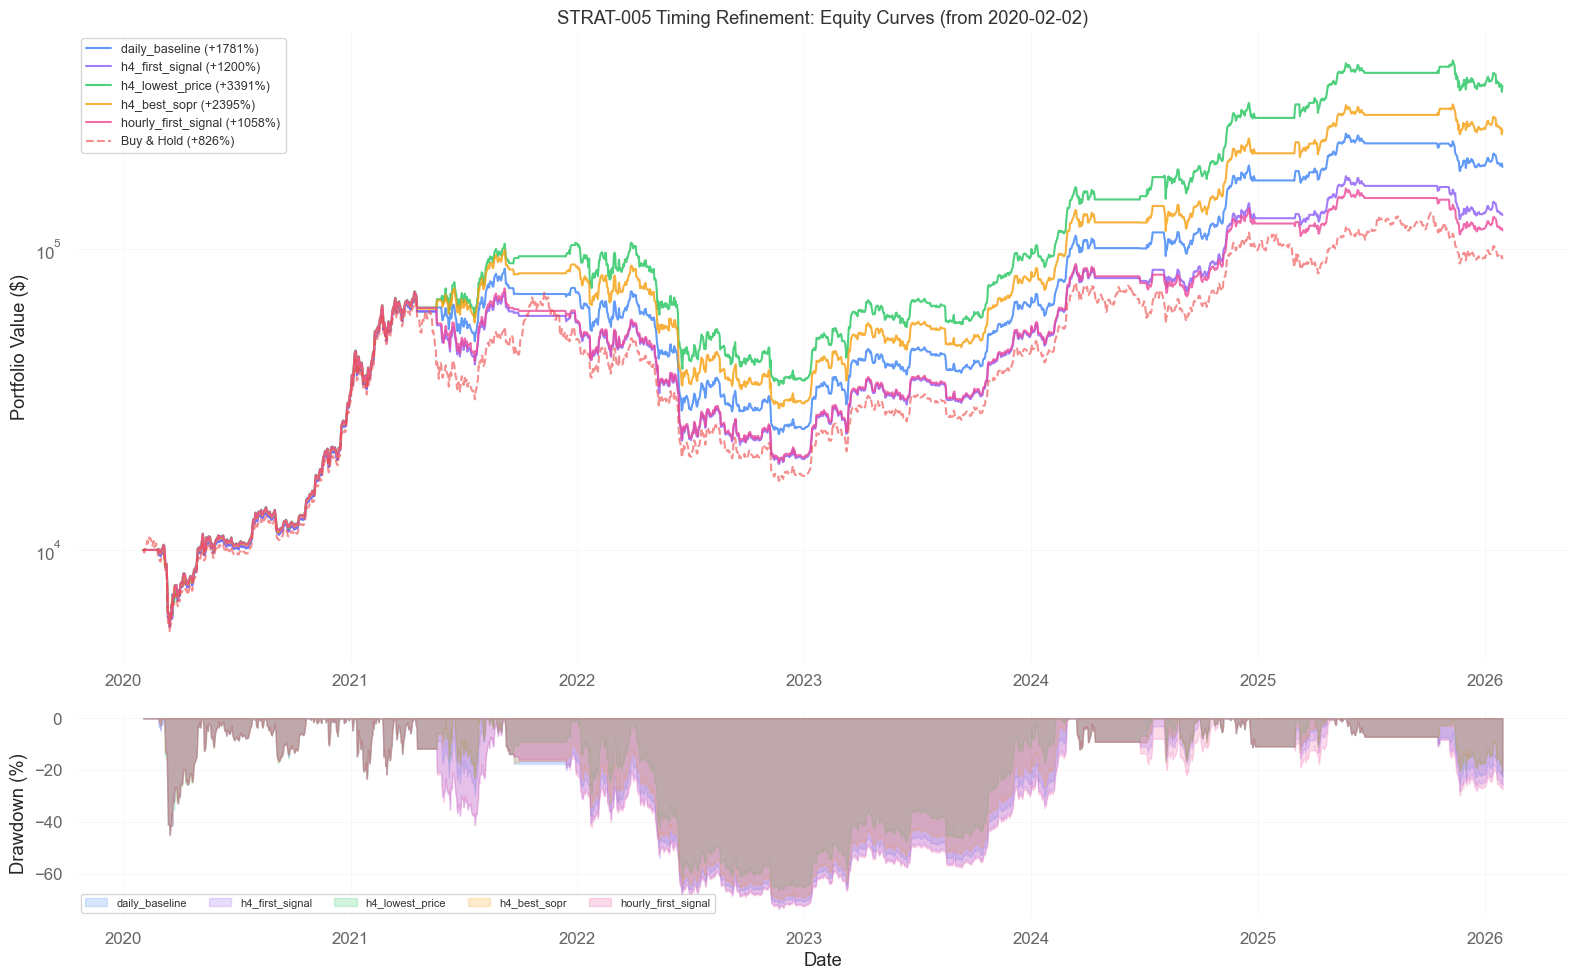

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

colors = {
    '1_daily_baseline':      '#3b82f6',
    '2_h4_first_signal':     '#8b5cf6',
    '3_h4_lowest_price':     '#22c55e',
    '4_h4_best_sopr':        '#f59e0b',
    '5_hourly_first_signal': '#ec4899',
}

# Equity curves
ax1 = axes[0]
for method_name, r in bt_results.items():
    pf = r['portfolio']
    equity = pf.value()
    label = method_name.split('_', 1)[1]
    ax1.plot(equity.index, equity.values, label=f"{label} ({r['total_return']:+.0f}%)",
             color=colors.get(method_name, '#888'), alpha=0.8, linewidth=1.5)

# Buy & hold
bh_equity = 10_000 * daily_df['price'] / daily_df['price'].iloc[0]
ax1.plot(bh_equity.index, bh_equity.values, label=f'Buy & Hold ({bh_ret:+.0f}%)',
         color='#ef4444', linestyle='--', alpha=0.6)

ax1.set_ylabel('Portfolio Value ($)')
ax1.set_title('STRAT-005 Timing Refinement: Equity Curves (from 2020-02-02)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Drawdown comparison
ax2 = axes[1]
for method_name, r in bt_results.items():
    pf = r['portfolio']
    dd = pf.drawdown()
    label = method_name.split('_', 1)[1]
    ax2.fill_between(dd.index, dd.values * 100, 0, alpha=0.2,
                     color=colors.get(method_name, '#888'), label=label)

ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left', ncol=5, fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Key Findings

In [16]:
# Auto-generate summary
print('=' * 80)
print('STRAT-005 TIMING REFINEMENT — KEY FINDINGS')
print('=' * 80)

# 1. Average price improvement per method
print('\n1. AVERAGE PRICE IMPROVEMENT vs Daily Baseline:')
print('-' * 60)
for method in timing['method'].unique():
    if method == '1_daily_baseline':
        continue
    label = method.split('_', 1)[1]
    m = imp_df[imp_df['method'] == method]['improvement_pct']
    better = (m > 0).sum()
    total = len(m)
    print(f'  {label:>25s}: {m.mean():+.2f}% mean  |  {m.median():+.2f}% median  |  {better}/{total} trades improved')

# 2. Best risk-adjusted method
print('\n2. RISK-ADJUSTED PERFORMANCE:')
print('-' * 60)
sorted_methods = sorted(bt_results.items(), key=lambda x: x[1]['sharpe'], reverse=True)
for method_name, r in sorted_methods:
    label = method_name.split('_', 1)[1]
    print(f'  {label:>25s}: Sharpe {r["sharpe"]:.2f}  |  Return {r["total_return"]:+.0f}%  |  MaxDD {r["max_dd"]:.1f}%')
best_method = sorted_methods[0][0].split('_', 1)[1]
print(f'  → Best risk-adjusted: {best_method}')

# 3. Statistical significance
print('\n3. STATISTICAL SIGNIFICANCE:')
print('-' * 60)
if len(baseline_trades) > 0:
    br = baseline_trades['Return'].values
    for method_name, r in bt_results.items():
        if method_name == baseline_method:
            continue
        label = method_name.split('_', 1)[1]
        mt = r['portfolio'].trades.records_readable
        if len(mt) == 0:
            continue
        mr = mt['Return'].values
        n = min(len(br), len(mr))
        if n >= 3:
            _, p = stats.ttest_rel(mr[:n], br[:n])
            sig_str = 'SIGNIFICANT (p<0.05)' if p < 0.05 else f'NOT significant (p={p:.3f})'
            print(f'  {label:>25s}: {sig_str}')

# 4. Practical recommendation
print('\n4. PRACTICAL RECOMMENDATION:')
print('-' * 60)
best_return = sorted(bt_results.items(), key=lambda x: x[1]['total_return'], reverse=True)[0]
baseline_ret = bt_results[baseline_method]['total_return']
best_ret = best_return[1]['total_return']
improvement = best_ret - baseline_ret
best_label = best_return[0].split('_', 1)[1]

if improvement > 50:  # More than 50pp improvement
    print(f'  Best method ({best_label}) adds {improvement:+.0f}pp over daily baseline.')
    print(f'  RECOMMENDATION: Use {best_label} for live execution.')
elif improvement > 10:  # Marginal improvement
    print(f'  Best method ({best_label}) adds {improvement:+.0f}pp over daily baseline.')
    print(f'  RECOMMENDATION: Marginal improvement — use if operationally feasible.')
else:
    print(f'  Best method ({best_label}) adds only {improvement:+.0f}pp over daily baseline.')
    print(f'  RECOMMENDATION: Stick with daily-only execution. Timing refinement adds')
    print(f'  complexity without meaningful improvement.')

print('\n' + '=' * 80)

STRAT-005 TIMING REFINEMENT — KEY FINDINGS

1. AVERAGE PRICE IMPROVEMENT vs Daily Baseline:
------------------------------------------------------------
            h4_first_signal: -0.88% mean  |  -0.43% median  |  65/180 trades improved
            h4_lowest_price: +2.98% mean  |  +2.22% median  |  180/180 trades improved
               h4_best_sopr: +1.12% mean  |  +0.71% median  |  130/180 trades improved
        hourly_first_signal: -1.15% mean  |  -0.74% median  |  64/180 trades improved

2. RISK-ADJUSTED PERFORMANCE:
------------------------------------------------------------
            h4_lowest_price: Sharpe 1.41  |  Return +3391%  |  MaxDD -66.5%
               h4_best_sopr: Sharpe 1.38  |  Return +2395%  |  MaxDD -70.2%
             daily_baseline: Sharpe 1.33  |  Return +1781%  |  MaxDD -71.8%
            h4_first_signal: Sharpe 1.16  |  Return +1200%  |  MaxDD -73.2%
        hourly_first_signal: Sharpe 1.11  |  Return +1058%  |  MaxDD -73.6%
  → Best risk-adjusted: h4_lo